

# **Project Number 5**
---



> - Full Name: **[Narges Kari]**
> - Student ID: **[402110821]**
---------------------------------
> - Full Name: **[Sana Niroomand]**
> - Student ID: **[402171104]**
--------------------------------
> - Full Name: **[Soroush Davaran]**
> - Student ID: **[402105987]**



## **FAZE 1**

**Setup**

First, we install the required packages and set a seed inhence of Reproducibility

In [4]:
# ---- Basic imports ----
import os, random
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

# ---- Reproducibility ----
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make runs more deterministic (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch: 2.10.0+cu128
cuda available: True
device: cuda


**Data Loading + Preprocessing Pipelin**


At this part we will download and load Dataset FashionMNIST and define a preprocessing pipeline which "ToTensor" transfor pictures to tensor and change the pixels from [0,255] to [0,1]

In [5]:
# ---- Config ----
BATCH_SIZE = 128
VAL_RATIO = 0.10
NUM_WORKERS = 0

# ---- Preprocessing pipeline ----
# Output: tensor in [0,1] with shape [1,28,28]
transform = transforms.ToTensor()

# ---- Download/load Fashion-MNIST ----
data_root = "./data"

full_train = datasets.FashionMNIST(root=data_root, train=True, download=True, transform=transform)
test_ds     = datasets.FashionMNIST(root=data_root, train=False, download=True, transform=transform)

# ---- Report counts and sample shape ----
print("Full train size:", len(full_train))
print("Test size      :", len(test_ds))

x0, y0 = full_train[0]
print("One sample x shape:", x0.shape, "| dtype:", x0.dtype, "| min/max:", float(x0.min()), float(x0.max()))
print("One sample y (label id):", int(y0))
print("Class names:", full_train.classes)


Full train size: 60000
Test size      : 10000
One sample x shape: torch.Size([1, 28, 28]) | dtype: torch.float32 | min/max: 0.0 1.0
One sample y (label id): 9
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


**Train/Val Split + DataLoaders**
 <div dir="rtl">
هدف این بخش:

جدا کردن یک validation set از train (مثلاً 10٪)

ساخت DataLoader برای train/val/test

چرا validation لازم داریم؟
برای اینکه موقع آموزش، فقط روی train قضاوت نکنیم و بفهمیم مدل داره overfit می‌شه یا نه.

نکات فنی:

از random_split با seed ثابت استفاده می‌کنیم تا split همیشه یکسان باشه.

pin_memory=True وقتی GPU داریم باعث سرعت بهتر انتقال batchها به GPU می‌شود.

خروجی مورد انتظار:

تعداد train/val/test

شکل یک batch: x: [B,1,28,28] و y: [B]
<div>

In [6]:
# ---- Split train into train/val ----
n_total = len(full_train)
n_val   = int(n_total * VAL_RATIO)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(full_train, [n_train, n_val], generator=generator)

print("Train size:", len(train_ds))
print("Val size  :", len(val_ds))
print("Test size :", len(test_ds))

# ---- DataLoaders ----
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# quick sanity: one batch tensor shapes
xb, yb = next(iter(train_loader))
print("One batch x:", xb.shape, xb.dtype, "| y:", yb.shape, yb.dtype)

Train size: 54000
Val size  : 6000
Test size : 10000
One batch x: torch.Size([128, 1, 28, 28]) torch.float32 | y: torch.Size([128]) torch.int64


**Sanity Check Visualization (>=25 Images)**

هدف این بخش:

مطمئن بشیم داده‌ها درست لود شدند و labelها با تصویر هماهنگ هستند

نمایش حداقل ۲۵ تصویر از یک batch به همراه نام کلاس

چرا مهمه؟
قبل از اینکه وارد آموزش مدل بشیم، باید مطمئن باشیم pipeline خراب نیست (مثلاً labelها جابجا نشده، شکل‌ها درست هستند، تصاویر سیاه نشده‌اند و…).

خروجی مورد انتظار:

یک grid از ۲۵ تصویر با عنوان کلاس‌ها

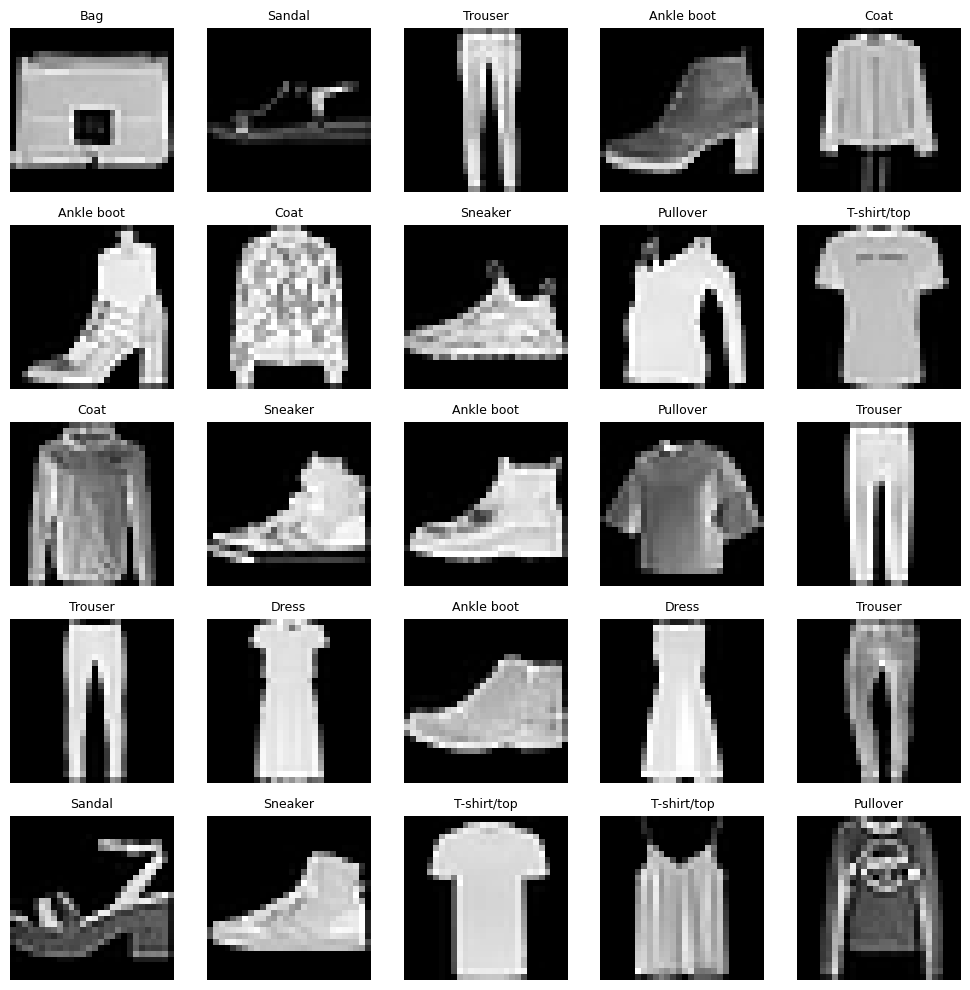

In [7]:
# ---- Show >= 25 images with labels ----
def show_batch(images, labels, classes, n=25):
    images = images[:n]
    labels = labels[:n]

    k = int(np.ceil(np.sqrt(n)))  # grid size
    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(k, k, i+1)
        plt.imshow(images[i].squeeze(0), cmap="gray")
        plt.title(classes[int(labels[i])], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

xb, yb = next(iter(train_loader))
show_batch(xb, yb, full_train.classes, n=25)

**EDA (Exploratory Data Analysis)**

<div dir= 'rtl'>

هدف این بخش (EDA):
طبق صورت پروژه، باید چند تحلیل ساده روی داده‌ها انجام بدیم تا دیتاست رو بهتر بشناسیم:

توزیع کلاس‌ها در train split (کلاس‌ها balanced هستند یا نه)

هیستوگرام شدت پیکسل‌ها (بیشتر زمینه‌ها تاریک‌اند یا روشن؟)

هیستوگرام میانگین شدت هر تصویر (تصاویر عمدتاً روشن/تاریک‌اند یا mix؟)

این تحلیل‌ها هم برای گزارش خوبه، هم برای تصمیم‌های بعدی مثل انتخاب loss و نرمال‌سازی.


EDA-1: Class Distribution
در این نمودار تعداد نمونه‌های هر کلاس در train split را می‌بینیم.

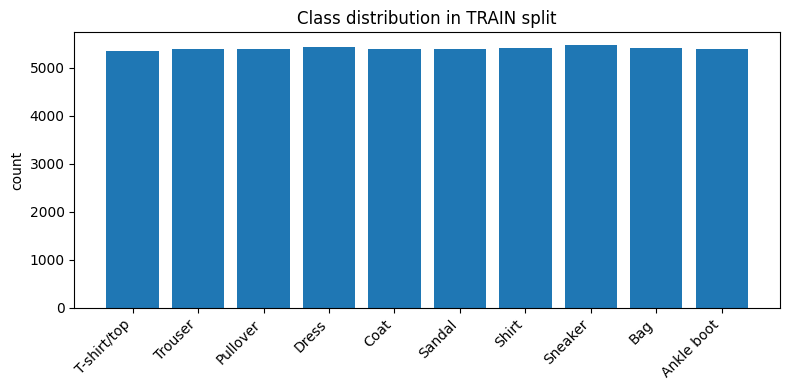

In [8]:
train_indices = train_ds.indices  # Subset indices into full_train

targets_all = full_train.targets  # tensor [60000]
train_targets = targets_all[train_indices]

class_counts = torch.bincount(train_targets, minlength=10).cpu().numpy()

plt.figure(figsize=(8,4))
plt.bar(range(10), class_counts)
plt.xticks(range(10), full_train.classes, rotation=45, ha="right")
plt.title("Class distribution in TRAIN split")
plt.ylabel("count")
plt.tight_layout()
plt.show()

**EDA-2: Pixel Intensity Histogram**



اینجا توزیع شدت پیکسل‌ها را روی کل train (در scale اصلی 0..255) بررسی می‌کنیم.

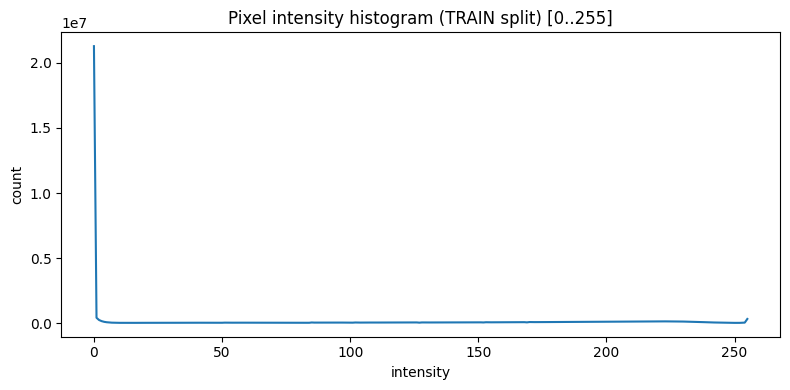

In [9]:
# full_train.data is uint8 [60000,28,28] in [0..255]
train_pixels = full_train.data[train_indices].reshape(-1).numpy()  # uint8
hist, bins = np.histogram(train_pixels, bins=256, range=(0, 255))

plt.figure(figsize=(8,4))
plt.plot(hist)
plt.title("Pixel intensity histogram (TRAIN split) [0..255]")
plt.xlabel("intensity")
plt.ylabel("count")
plt.tight_layout()
plt.show()

<div dir= 'rtl'>
«قله‌ی بزرگ در شدت‌های نزدیک ۰ نشان می‌دهد اکثر پیکسل‌ها مربوط به پس‌زمینه‌ی تیره هستند؛ دُم توزیع تا نزدیکی ۱ بیانگر پیکسل‌های روشن‌تر در نواحی لباس/مرزهاست.»

**EDA-3: Per-image Mean Intensity**


در این نمودار، برای هر تصویر میانگین شدت پیکسل محاسبه می‌شود (در بازه 0..1) و سپس هیستوگرام آن رسم می‌شود.

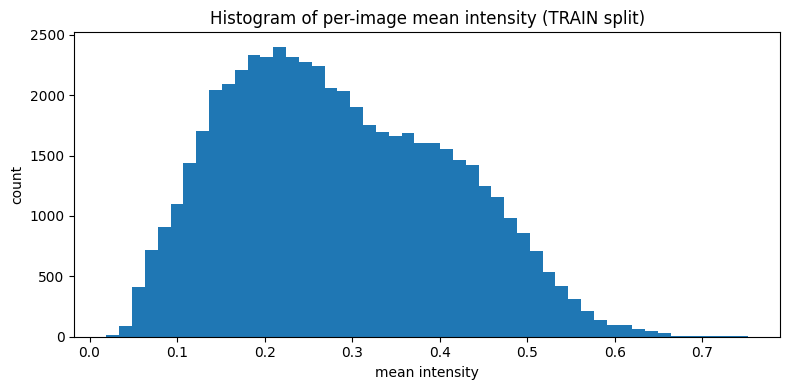

In [10]:
img_means = full_train.data[train_indices].float().mean(dim=(1,2)) / 255.0
img_means = img_means.numpy()

plt.figure(figsize=(8,4))
plt.hist(img_means, bins=50)
plt.title("Histogram of per-image mean intensity (TRAIN split)")
plt.xlabel("mean intensity")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## **FAZE 2**
**Baseline VAE (From Scratch)**

In [11]:
# -----------------------
# VAE Baseline Config
# -----------------------
LATENT_DIM = 16
HIDDEN1 = 400
HIDDEN2 = 200

LR = 1e-3
EPOCHS = 10
BETA = 1.0  # weight of regularization term (baseline must be 1)

# Reconstruction loss choice: BCE (fixed for the whole project)
RECON_LOSS_TYPE = "bce_logits"  # we use BCEWithLogitsLoss-style

print("latent_dim:", LATENT_DIM, "| epochs:", EPOCHS, "| lr:", LR, "| beta:", BETA)

latent_dim: 16 | epochs: 10 | lr: 0.001 | beta: 1.0


**Model (Encoder/Decoder/VAE)**

<div dir= 'rtl'>
هدف این بخش:
پیاده‌سازی مدل از صفر شامل:

Encoder: تصویر 28×28 را flatten می‌کند و به دو بردار mu و logvar می‌رسد.

Reparameterization trick: نمونه‌گیری قابل‌گرادیان از

z∼q(z∣x).

Decoder: از
𝑧
z به فضای تصویر برمی‌گردد و logits تولید می‌کند (نه sigmoid) تا loss پایدارتر باشد.
این دقیقاً همان الزام “from scratch + reparameterization + encoder/decoder” است.

In [12]:
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, latent_dim=16, h1=400, h2=200):
        super().__init__()
        self.fc1 = nn.Linear(28*28, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc_mu = nn.Linear(h2, latent_dim)
        self.fc_logvar = nn.Linear(h2, latent_dim)

    def forward(self, x):
        # x: [B,1,28,28]
        x = x.view(x.size(0), -1)  # [B,784]
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim=16, h2=200, h1=400):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, h2)
        self.fc2 = nn.Linear(h2, h1)
        self.fc_out = nn.Linear(h1, 28*28)  # output logits

    def forward(self, z):
        h = F.relu(self.fc1(z))
        h = F.relu(self.fc2(h))
        logits = self.fc_out(h)  # [B,784]
        logits = logits.view(z.size(0), 1, 28, 28)
        return logits

class VAE(nn.Module):
    def __init__(self, latent_dim=16, h1=400, h2=200):
        super().__init__()
        self.encoder = Encoder(latent_dim, h1, h2)
        self.decoder = Decoder(latent_dim, h2, h1)

    @staticmethod
    def reparameterize(mu, logvar):
        # z = mu + eps * sigma
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z)
        return logits, mu, logvar

**Loss functions**

<div dir= 'rtl'>
هدف این بخش (Loss):
طبق پروژه، تابع هزینه باید شامل:

Reconstruction loss (یکی از BCE یا MSE و باید ثابت بماند)

Regularization term روی latent (در حالت پایه وزن ۱)

در VAE معمولاً regularization همان KL divergence بین

q(z∣x) و
𝑁
(
0
,
𝐼
)
 است.
ما در گزارش هر epoch و روی test سه عدد را جداگانه ذخیره و چاپ می‌کنیم: recon, kl, total

In [13]:
def kl_divergence(mu, logvar):
    # KL(q(z|x) || N(0,1)) per-sample
    # = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # [B]
    return kl  # per-sample

def reconstruction_loss_logits(x, logits):
    # x in [0,1], logits unbounded
    # BCEWithLogits is stable and common for [0,1] pixel data
    bce = F.binary_cross_entropy_with_logits(
        logits, x, reduction="none"
    )  # [B,1,28,28]
    bce = bce.view(bce.size(0), -1).sum(dim=1)  # sum over pixels => [B]
    return bce  # per-sample

def vae_loss(x, logits, mu, logvar, beta=1.0):
    recon = reconstruction_loss_logits(x, logits)    # [B]
    kl = kl_divergence(mu, logvar)                   # [B]
    total = recon + beta * kl                        # [B]
    # return averages for reporting
    return recon.mean(), kl.mean(), total.mean()

**Train/Eval loops**
<div dir= 'rtl'>
هدف این بخش:
نوشتن حلقه‌های آموزش و ارزیابی به شکل تمیز و قابل گزارش‌دهی:

train_one_epoch: آموزش روی train و گزارش میانگین lossها

evaluate: ارزیابی روی val/test بدون گرادیان
این بخش مستقیماً برای الزام “گزارش روی test: reconstruction/regularization/total” استفاده می‌شود.

In [14]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    recon_sum = 0.0
    kl_sum = 0.0
    total_sum = 0.0
    n_batches = 0

    for x, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits, mu, logvar = model(x)
        recon, kl, total = vae_loss(x, logits, mu, logvar, beta=beta)

        total.backward()
        optimizer.step()

        recon_sum += recon.item()
        kl_sum += kl.item()
        total_sum += total.item()
        n_batches += 1

    return {
        "recon": recon_sum / n_batches,
        "kl": kl_sum / n_batches,
        "total": total_sum / n_batches
    }

@torch.no_grad()
def evaluate(model, loader, device, beta=1.0, desc="eval"):
    model.eval()
    recon_sum = 0.0
    kl_sum = 0.0
    total_sum = 0.0
    n_batches = 0

    for x, _ in tqdm(loader, desc=desc, leave=False):
        x = x.to(device)
        logits, mu, logvar = model(x)
        recon, kl, total = vae_loss(x, logits, mu, logvar, beta=beta)

        recon_sum += recon.item()
        kl_sum += kl.item()
        total_sum += total.item()
        n_batches += 1

    return {
        "recon": recon_sum / n_batches,
        "kl": kl_sum / n_batches,
        "total": total_sum / n_batches
    }

**Train baseline VAE**
<div dir= 'rtl'>
هدف این بخش:

ساخت مدل VAE، optimizer و اجرای آموزش چند epoch

ذخیره history برای اینکه بعداً در گزارش/مقایسه baseline و improved از آن استفاده کنیم

In [15]:
vae = VAE(latent_dim=LATENT_DIM, h1=HIDDEN1, h2=HIDDEN2).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

history = {"train": [], "val": []}

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(vae, train_loader, optimizer, device, beta=BETA)
    val_metrics   = evaluate(vae, val_loader, device, beta=BETA, desc="val")

    history["train"].append(train_metrics)
    history["val"].append(val_metrics)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train total={train_metrics['total']:.2f} (recon={train_metrics['recon']:.2f}, kl={train_metrics['kl']:.2f}) | "
          f"val total={val_metrics['total']:.2f} (recon={val_metrics['recon']:.2f}, kl={val_metrics['kl']:.2f})")

train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 01/10 | train total=294.47 (recon=284.44, kl=10.03) | val total=262.15 (recon=251.37, kl=10.78)


train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/47 [00:00<?, ?it/s]

...

val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 09/10 | train total=241.40 (recon=229.71, kl=11.69) | val total=242.53 (recon=230.72, kl=11.81)


train:   0%|          | 0/422 [00:00<?, ?it/s]

val:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10/10 | train total=241.00 (recon=229.25, kl=11.75) | val total=242.13 (recon=230.55, kl=11.57)


**Test report**
<div dir = 'rtl'>
هدف این بخش (گزارش روی test):
طبق پروژه باید روی test set سه مقدار را گزارش کنیم:

reconstruction, regularization, total.


In [16]:
test_metrics = evaluate(vae, test_loader, device, beta=BETA, desc="test")
print("TEST metrics:")
print(test_metrics)  # {"recon": ..., "kl": ..., "total": ...}

test:   0%|          | 0/79 [00:00<?, ?it/s]

TEST metrics:
{'recon': 231.31486569175237, 'kl': 11.498989201799224, 'total': 242.81385416924198}


**Show >=20 reconstructions (input vs recon)**
<div dir= 'rtl'>
هدف این بخش (Reconstruction samples):

طبق پروژه باید حداقل ۲۰ تصویر ورودی/خروجی بازسازی را نمایش دهیم.
اینجا از چند نمونه‌ی test استفاده می‌کنیم و کنار هم می‌گذاریم: ردیف بالا ورودی، ردیف پایین بازسازی.
<div>

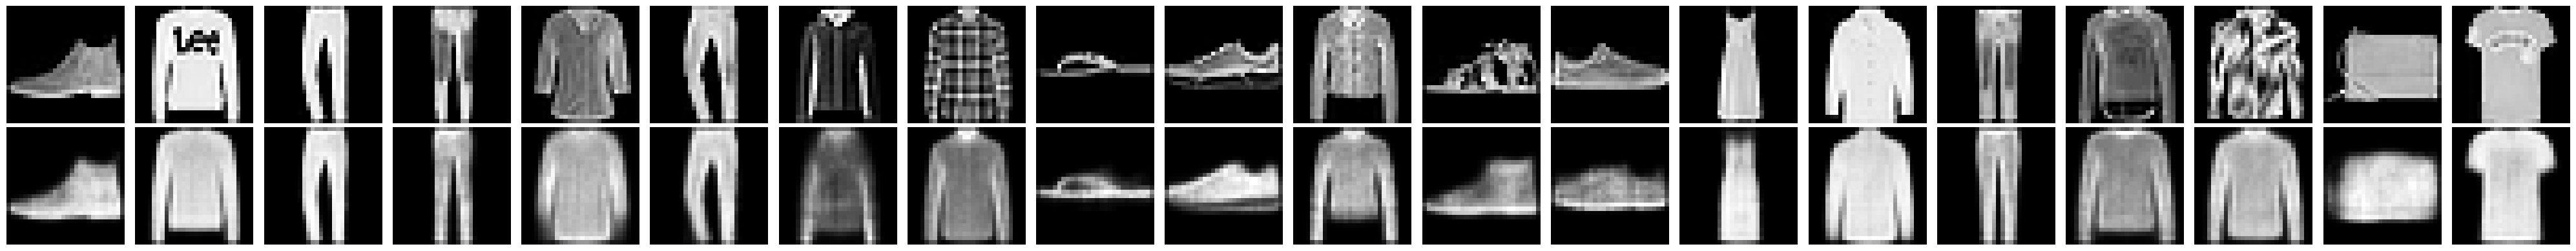

In [17]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=20):
    model.eval()
    x, y = next(iter(loader))
    x = x.to(device)[:n]

    logits, _, _ = model(x)
    x_hat = torch.sigmoid(logits)  # convert logits -> [0,1] for visualization

    # plot: 2 rows, n columns
    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # original
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].squeeze(0).cpu(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("input", fontsize=12)

        # reconstructed
        plt.subplot(2, n, n+i+1)
        plt.imshow(x_hat[i].squeeze(0).cpu(), cmap="gray")
        plt.axis("off")
        if i == 0:
            plt.ylabel("recon", fontsize=12)

    plt.tight_layout()
    plt.show()

show_reconstructions(vae, test_loader, device, n=20)

**Show >=50 samples from prior**

هدف این بخش (Sampling):
طبق پروژه باید حداقل ۵۰ تصویر با sampling از فضای نهفته نمایش دهیم.
اینجا از prior یعنی
𝑧
∼
𝑁
(
0
,
𝐼
)
 نمونه می‌گیریم و decode می‌کنیم.

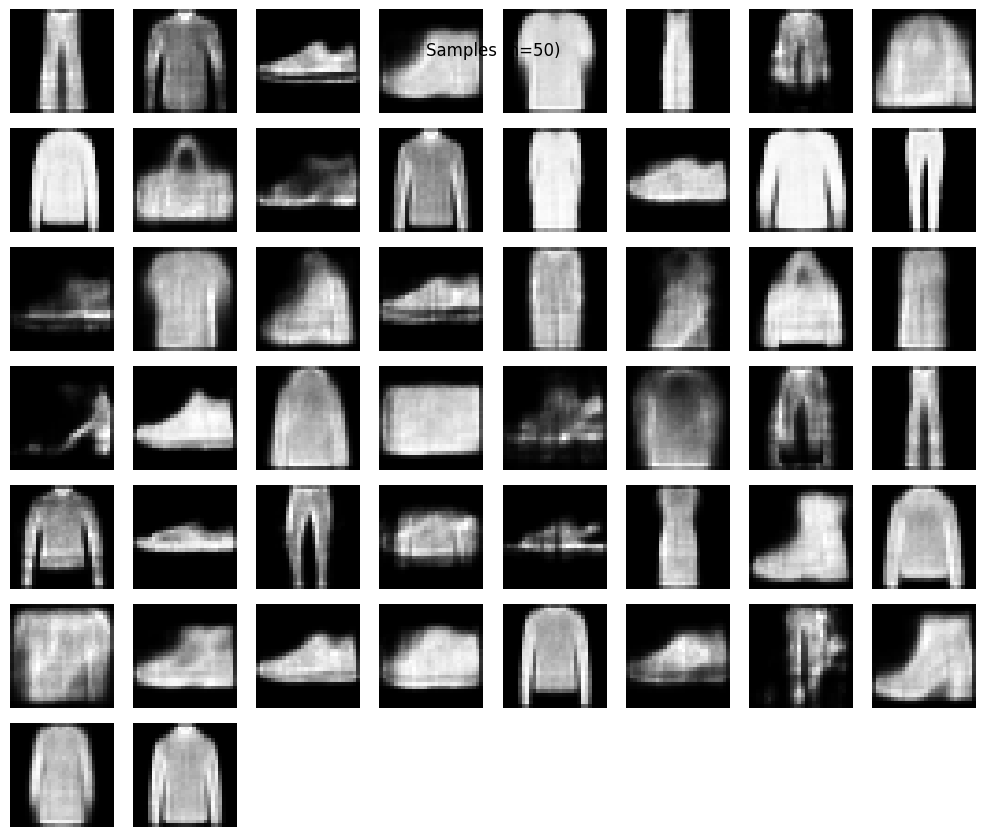

In [18]:
@torch.no_grad()
def show_samples(model, device, n=50, latent_dim=16):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decoder(z)
    samples = torch.sigmoid(logits).cpu()  # [n,1,28,28]

    k = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(k, k, i+1)
        plt.imshow(samples[i].squeeze(0), cmap="gray")
        plt.axis("off")
    plt.suptitle(f"Samples (n={n})", y=0.92)
    plt.tight_layout()
    plt.show()

show_samples(vae, device, n=50, latent_dim=LATENT_DIM)

## **improve output Quality and Competition standard**

**Improved Model: Convolutional VAE**

<div dir= 'rtl'>
مدل پایه MLP معمولاً برای تصویر کیفیت محدودتری دارد. با تبدیل Encoder/Decoder به Conv/Deconv، مدل بهتر می‌تواند الگوهای مکانی (لبه‌ها، بافت‌ها) را یاد بگیرد، و معمولاً sampling و reconstruction طبیعی‌تر می‌شود. این دقیقاً یکی از گزینه‌های مجاز برای “بهبود کیفیت خروجی” است.

In [19]:
test_metrics_baseline = test_metrics
print("baseline:", test_metrics_baseline)

baseline: {'recon': 231.31486569175237, 'kl': 11.498989201799224, 'total': 242.81385416924198}


**ConvVAE model**
<div dir= 'rtl'>
پیاده‌سازی ConvVAE:

Encoder: چند لایه کانولوشن با stride=2 برای downsample تا ویژگی‌های فشرده

تولید mu و logvar

Decoder: از latent به feature map و سپس upsample با ConvTranspose

خروجی logits (برای BCEWithLogits پایدارتر)

Reconstruction loss و KL دقیقاً همان قبلی می‌ماند (فقط معماری عوض می‌شود) تا مقایسه منصفانه باشد.

In [20]:
import torch.nn as nn
import torch.nn.functional as F

class ConvEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        # [B,1,28,28] -> [B,32,14,14]
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        # -> [B,64,7,7]
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        # keep size 7x7, increase channels
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)

        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        h = h.view(h.size(0), -1)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

class ConvDecoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 7 * 7)

        # [B,128,7,7] -> [B,64,14,14]
        self.deconv1 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)
        # -> [B,32,28,28]
        self.deconv2 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        # -> [B,1,28,28] logits
        self.conv_out = nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, z):
        h = F.relu(self.fc(z))
        h = h.view(z.size(0), 128, 7, 7)
        h = F.relu(self.deconv1(h))
        h = F.relu(self.deconv2(h))
        logits = self.conv_out(h)
        return logits

class ConvVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.encoder = ConvEncoder(latent_dim)
        self.decoder = ConvDecoder(latent_dim)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z)
        return logits, mu, logvar

**Train improved model**
<div dir= 'rtl'>
آموزش ConvVAE با همان loss قبلی (BCEWithLogits + KL) و گزارش train/val.
این مدل “improved” ماست و بعداً روی test با baseline مقایسه می‌شود (جدول + تصاویر).

In [21]:
LATENT_DIM_IMP = 32
EPOCHS_IMP = 12
LR_IMP = 1e-3
BETA_IMP = 1.0
vae_conv = ConvVAE(latent_dim=LATENT_DIM_IMP).to(device)
opt_conv = torch.optim.Adam(vae_conv.parameters(), lr=LR_IMP)

hist_conv = {"train": [], "val": []}

for epoch in range(1, EPOCHS_IMP + 1):
    tr = train_one_epoch(vae_conv, train_loader, opt_conv, device, beta=BETA_IMP)
    va = evaluate(vae_conv, val_loader, device, beta=BETA_IMP, desc="val-conv")

    hist_conv["train"].append(tr)
    hist_conv["val"].append(va)

    print(f"[ConvVAE] Epoch {epoch:02d}/{EPOCHS_IMP} | "
          f"train total={tr['total']:.2f} (recon={tr['recon']:.2f}, kl={tr['kl']:.2f}) | "
          f"val total={va['total']:.2f} (recon={va['recon']:.2f}, kl={va['kl']:.2f})")

train:   0%|          | 0/422 [00:00<?, ?it/s]

val-conv:   0%|          | 0/47 [00:00<?, ?it/s]

[ConvVAE] Epoch 01/12 | train total=291.22 (recon=276.19, kl=15.03) | val total=257.14 (recon=241.14, kl=16.00)


train:   0%|          | 0/422 [00:00<?, ?it/s]

val-conv:   0%|          | 0/47 [00:00<?, ?it/s]

...

val-conv:   0%|          | 0/47 [00:00<?, ?it/s]

[ConvVAE] Epoch 11/12 | train total=238.51 (recon=221.40, kl=17.11) | val total=239.77 (recon=221.89, kl=17.88)


train:   0%|          | 0/422 [00:00<?, ?it/s]

val-conv:   0%|          | 0/47 [00:00<?, ?it/s]

[ConvVAE] Epoch 12/12 | train total=238.19 (recon=221.04, kl=17.15) | val total=239.34 (recon=222.07, kl=17.27)


**Test metrics + comparison table**

گزارش روی test set و ساخت جدول مقایسه بین baseline و improved

In [22]:
import pandas as pd

test_metrics_conv = evaluate(vae_conv, test_loader, device, beta=BETA_IMP, desc="test-conv")
print("conv:", test_metrics_conv)

df_cmp = pd.DataFrame([
    {"model": "baseline_mlp", **test_metrics_baseline},
    {"model": "improved_conv", **test_metrics_conv},
])

# reorder columns
df_cmp = df_cmp[["model", "recon", "kl", "total"]]
df_cmp

test-conv:   0%|          | 0/79 [00:00<?, ?it/s]

conv: {'recon': 222.83233565318434, 'kl': 17.17967212049267, 'total': 240.01200634920144}


,model,recon,kl,total
0,baseline_mlp,231.314866,11.498989,242.813854
1,improved_conv,222.832336,17.179672,240.012006


**Recon comparison (before vs after)**

مایش چند نمونه reconstruction قبل/بعد و sampling قبل/بعد (الزام پروژه).

برای مقایسه، هر دو مدل را با یک تعداد تصویر یکسان نمایش می‌دهیم.

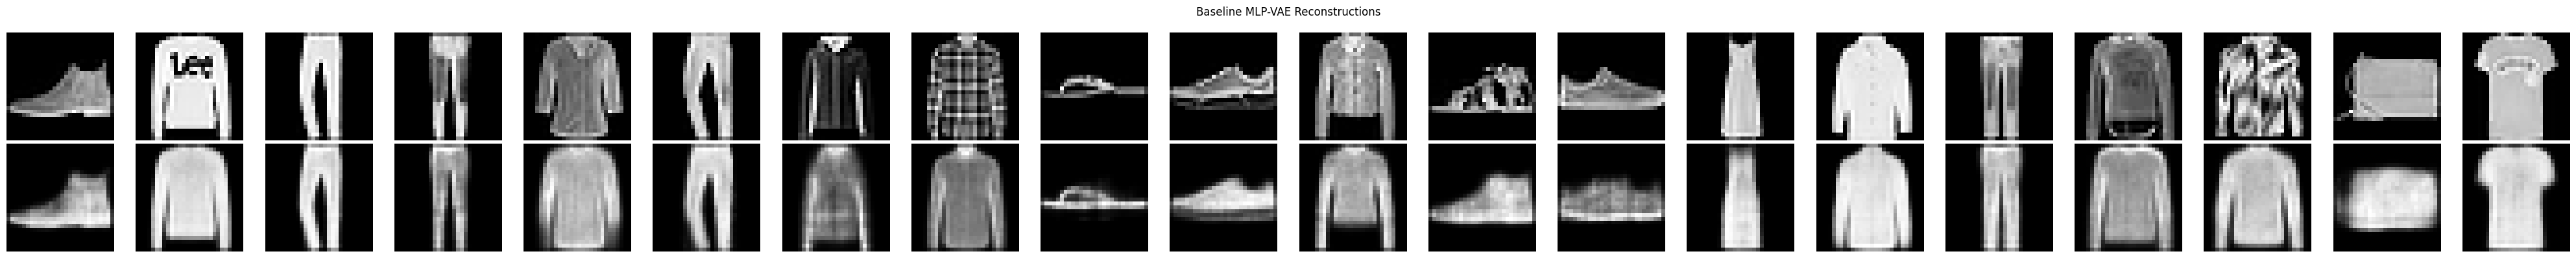

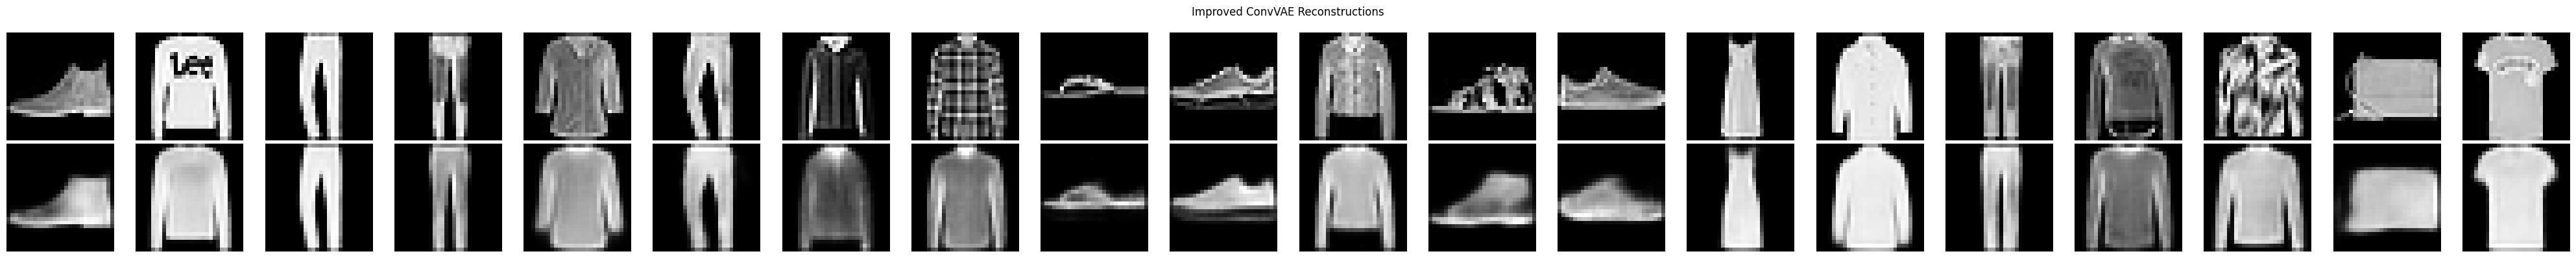

In [23]:
@torch.no_grad()
def recon_grid(model, loader, device, n=20, title=""):
    model.eval()
    x, _ = next(iter(loader))
    x = x.to(device)[:n]
    logits, _, _ = model(x)
    x_hat = torch.sigmoid(logits)

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(x[i].squeeze(0).cpu(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("input")

        plt.subplot(2, n, n+i+1)
        plt.imshow(x_hat[i].squeeze(0).cpu(), cmap="gray")
        plt.axis("off")
        if i == 0: plt.ylabel("recon")
    plt.suptitle(title, y=0.98)
    plt.tight_layout()
    plt.show()

recon_grid(vae, test_loader, device, n=20, title="Baseline MLP-VAE Reconstructions")
recon_grid(vae_conv, test_loader, device, n=20, title="Improved ConvVAE Reconstructions")

**Sampling comparison (before vs after)**

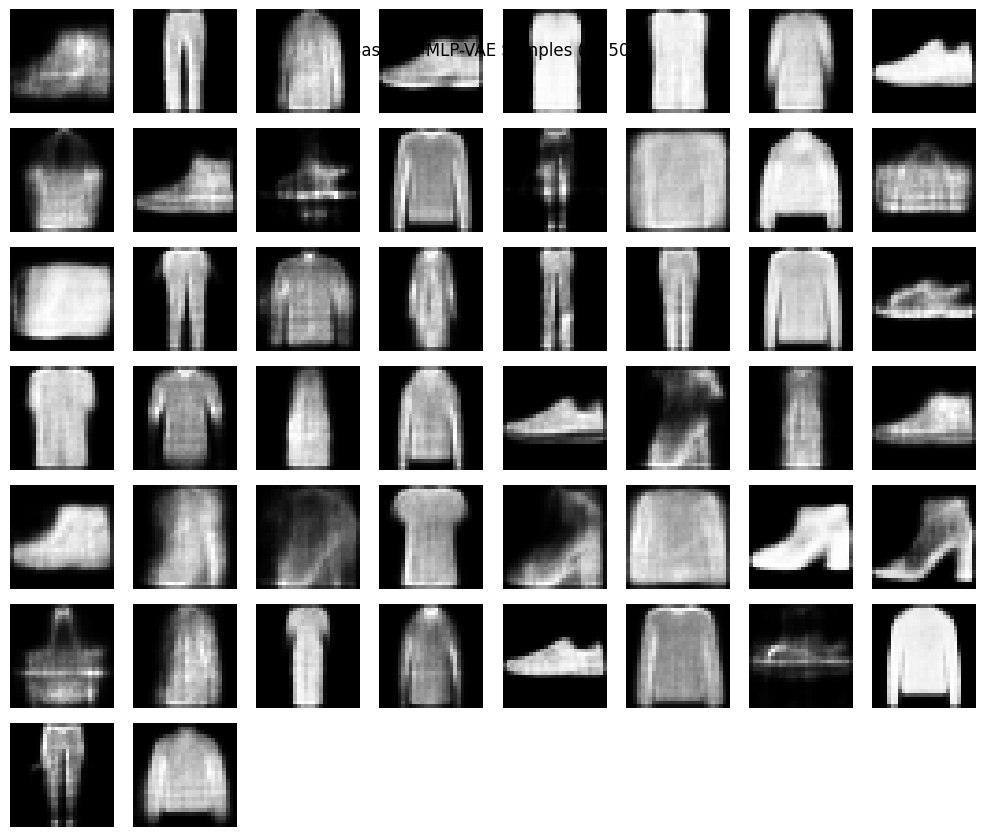

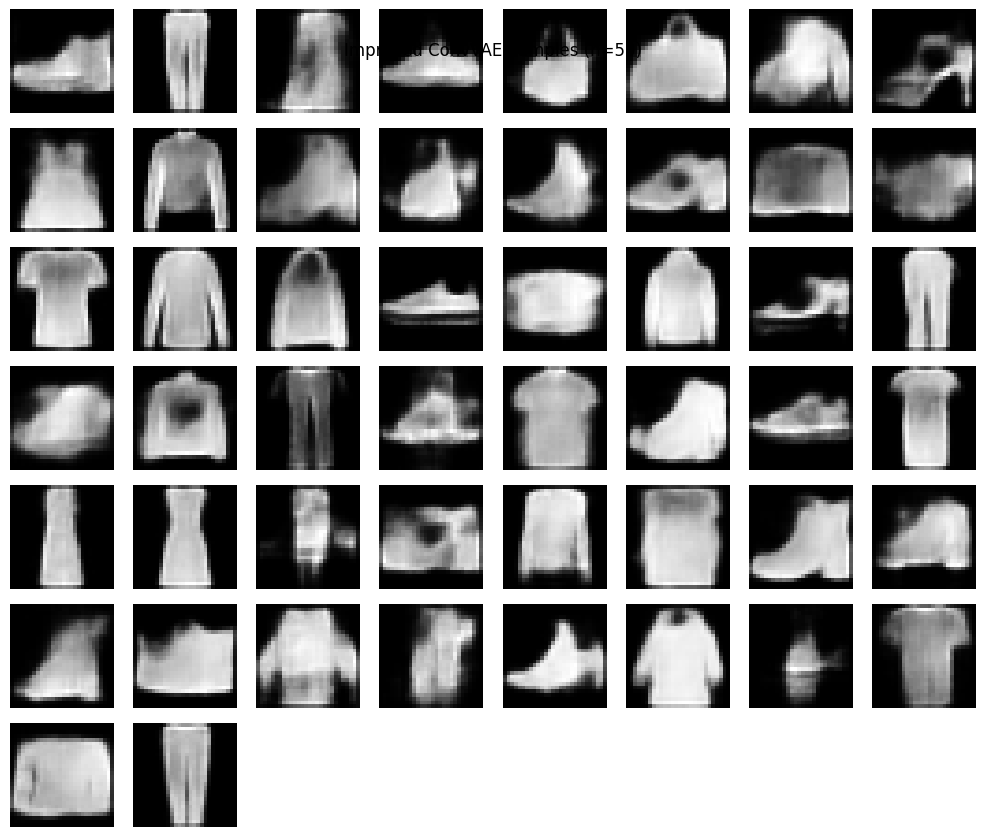

In [24]:
@torch.no_grad()
def sample_grid(model, device, latent_dim, n=50, title=""):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decoder(z)
    samples = torch.sigmoid(logits).cpu()

    k = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(10, 10))
    for i in range(n):
        plt.subplot(k, k, i+1)
        plt.imshow(samples[i].squeeze(0), cmap="gray")
        plt.axis("off")
    plt.suptitle(title, y=0.92)
    plt.tight_layout()
    plt.show()

sample_grid(vae, device, LATENT_DIM, n=50, title="Baseline MLP-VAE Samples (n=50)")
sample_grid(vae_conv, device, LATENT_DIM_IMP, n=50, title="Improved ConvVAE Samples (n=50)")

**Load classifier**

In [25]:
from pathlib import Path

path = Path("./classifier.py")
txt = path.read_text(encoding="utf-8")

header = (
    "import torch\n"
    "import torch.nn as nn\n"
    "from torchvision.models import resnet18\n\n"
)

if "import torch" not in txt or "import torch.nn as nn" not in txt or "resnet18" not in txt.splitlines()[0:20]:
    path.write_text(header + txt, encoding="utf-8")
    print("[OK] Added missing imports to /content/classifier.py")
else:
    print("[OK] Imports already present")

[OK] Added missing imports to /content/classifier.py


In [26]:
import os, sys, importlib.util
import torch
import numpy as np

CLASSIFIER_PY = "./classifier.py"
CLASSIFIER_WEIGHTS = "./fashion_resnet18_classifier.pt"

# Load the class dynamically
spec = importlib.util.spec_from_file_location("classifier_mod", CLASSIFIER_PY)
classifier_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(classifier_mod)

# Build model
clf = classifier_mod.FashionResNet18(num_classes=10).to(device)

# Load weights
ckpt = torch.load(CLASSIFIER_WEIGHTS, map_location=device)

# --- استخراج دیکشنری اصلی وزن‌ها بر اساس اروری که دیدیم ---
if "model_state_dict" in ckpt:
    state = ckpt["model_state_dict"]
elif "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

new_state = {}
for k, v in state.items():
    nk = k.replace("module.", "").replace("model.", "")

    if not nk.startswith("backbone.") and not nk.startswith("head."):
        if nk.startswith("fc."):
            nk = nk.replace("fc.", "head.")
        else:
            nk = "backbone." + nk

    new_state[nk] = v

try:
    clf.load_state_dict(new_state, strict=True)
    print("✅ Classifier weights loaded PERFECTLY! The beast is awake.")
except Exception as e:
    print("❌ Error loading weights:")
    print(e)

clf.eval()
for p in clf.parameters():
    p.requires_grad_(False)

print("Classifier is frozen and ready.")

✅ Classifier weights loaded PERFECTLY! The beast is awake.
Classifier is frozen and ready.


**Feature extractor + stats helpers**

In [27]:
from tqdm.auto import tqdm

@torch.no_grad()
def collect_features_real(clf, loader, device, max_items=None):
    clf.eval()
    feats_all = []
    n = 0
    for x, _ in tqdm(loader, desc="real feats"):
        x = x.to(device)
        _, feats = clf(x)  # feats: [B,512]  :contentReference[oaicite:4]{index=4}
        feats_all.append(feats.detach().cpu())
        n += x.size(0)
        if max_items is not None and n >= max_items:
            break
    feats_all = torch.cat(feats_all, dim=0)
    if max_items is not None:
        feats_all = feats_all[:max_items]
    return feats_all.numpy()

@torch.no_grad()
def collect_features_fake_from_vae(clf, vae_model, device, latent_dim, n_gen=10_000, batch_size=256):
    clf.eval()
    vae_model.eval()
    feats_all = []
    produced = 0
    pbar = tqdm(total=n_gen, desc="fake feats")

    while produced < n_gen:
        bs = min(batch_size, n_gen - produced)
        z = torch.randn(bs, latent_dim, device=device)
        logits = vae_model.decoder(z)
        x = torch.sigmoid(logits)  # [0,1] for classifier input
        _, feats = clf(x)
        feats_all.append(feats.detach().cpu())
        produced += bs
        pbar.update(bs)

    pbar.close()
    feats_all = torch.cat(feats_all, dim=0)
    return feats_all.numpy()

def compute_mean_cov(feats: np.ndarray):
    feats = feats.astype(np.float64)
    mu = feats.mean(axis=0)
    sigma = np.cov(feats, rowvar=False)
    return mu, sigma

def fid_from_stats(mu1, sigma1, mu2, sigma2):
    # FID = ||mu1-mu2||^2 + Tr(sigma1+sigma2 - 2*sqrtm(sigma1 sigma2))
    from scipy import linalg

    diff = mu1 - mu2
    covmean = linalg.sqrtm(sigma1 @ sigma2)

    # numeric stability: sqrtm can return complex due to precision
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff @ diff + np.trace(sigma1) + np.trace(sigma2) - 2.0 * np.trace(covmean)
    return float(fid)

**Real features from TEST**

In [28]:
real_feats = collect_features_real(clf, test_loader, device, max_items=10_000)
mu_real, sig_real = compute_mean_cov(real_feats)

print("Real feats shape:", real_feats.shape)

real feats:   0%|          | 0/79 [00:00<?, ?it/s]

Real feats shape: (10000, 512)


**FID**

In [29]:
fake_feats = collect_features_fake_from_vae(
    clf=clf,
    vae_model=vae_conv,
    device=device,
    latent_dim=LATENT_DIM_IMP,
    n_gen=10_000,
    batch_size=256
)

mu_fake, sig_fake = compute_mean_cov(fake_feats)
fid_conv = fid_from_stats(mu_real, sig_real, mu_fake, sig_fake)

print("FID (improved ConvVAE):", fid_conv)

fake feats:   0%|          | 0/10000 [00:00<?, ?it/s]

FID (improved ConvVAE): 9.798276519592235


In [30]:
fake_feats_base = collect_features_fake_from_vae(
    clf=clf,
    vae_model=vae,        # baseline MLP-VAE
    device=device,
    latent_dim=LATENT_DIM,
    n_gen=10_000,
    batch_size=256
)

mu_fb, sig_fb = compute_mean_cov(fake_feats_base)
fid_base = fid_from_stats(mu_real, sig_real, mu_fb, sig_fb)

print("FID (baseline MLP-VAE):", fid_base)
print("FID improvement (base - conv):", fid_base - fid_conv)

fake feats:   0%|          | 0/10000 [00:00<?, ?it/s]

FID (baseline MLP-VAE): 9.400982374659193
FID improvement (base - conv): -0.39729414493304205


## **FAZE 3**


<div dir ='rtl'>

**تنظیمات β و هایپرپارامترها**


با تغییر β (وزن ترم KL)، روی trade-off بین «کیفیت بازسازی» و «تفسیرپذیری latent» کنترل می‌گیریم.
β کوچک‌تر ⇒ بازسازی بهتر، latent آزادتر/کمتر ساختارمند
β بزرگ‌تر ⇒ latent منظم‌تر/قابل‌تفسیرتر، اما بازسازی معمولاً بدتر


In [31]:
# Phase 3 settings
BETAS = [0.6, 0.9, 5.0]   # suggested by project example
EPOCHS_BETA = 10
LR_BETA = 1e-3

LATENT_DIM_BETA = 32   # same as your improved ConvVAE
print("BETAS:", BETAS, "| epochs:", EPOCHS_BETA, "| latent:", LATENT_DIM_BETA)

BETAS: [0.6, 0.9, 5.0] | epochs: 10 | latent: 32



<div dir ='rtl'>

**آموزش مدل برای هر β + ذخیره نتایج test**

برای هر β یک مدل ConvVAE جدا آموزش می‌دهیم (β-VAE). سپس روی test سه مقدار را گزارش می‌کنیم:

recon (reconstruction loss)

kl (regularization term)

total = recon + β * kl

پیش‌نیاز: توی نوت‌بوکت باید این‌ها موجود باشن: ConvVAE, train_one_epoch, evaluate, device, و DataLoaderها. (همه‌ش رو قبلاً ساختیم.)

In [32]:
import pandas as pd
import torch

# Keep results here
beta_models = {}
beta_test_rows = []

def train_convvae_for_beta(beta, epochs=10, lr=1e-3, latent_dim=32):
    # re-seed for fair-ish comparison
    set_seed(SEED)

    model = ConvVAE(latent_dim=latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for ep in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, opt, device, beta=beta)
        va = evaluate(model, val_loader, device, beta=beta, desc=f"val β={beta}")
        print(f"[β={beta}] Epoch {ep:02d}/{epochs} | "
              f"train total={tr['total']:.2f} (recon={tr['recon']:.2f}, kl={tr['kl']:.2f}) | "
              f"val total={va['total']:.2f} (recon={va['recon']:.2f}, kl={va['kl']:.2f})")
    return model

for beta in BETAS:
    print("\n" + "="*60)
    print("Training beta =", beta)
    print("="*60)

    model_beta = train_convvae_for_beta(beta, epochs=EPOCHS_BETA, lr=LR_BETA, latent_dim=LATENT_DIM_BETA)
    beta_models[beta] = model_beta

    test_m = evaluate(model_beta, test_loader, device, beta=beta, desc=f"test β={beta}")
    beta_test_rows.append({"beta": beta, **test_m})

df_beta_test = pd.DataFrame(beta_test_rows).sort_values("beta")
df_beta_test = df_beta_test[["beta", "recon", "kl", "total"]]
df_beta_test


Training beta = 0.6


train:   0%|          | 0/422 [00:00<?, ?it/s]

val β=0.6:   0%|          | 0/47 [00:00<?, ?it/s]

[β=0.6] Epoch 01/10 | train total=283.16 (recon=270.69, kl=20.79) | val total=248.20 (recon=233.97, kl=23.72)


train:   0%|          | 0/422 [00:00<?, ?it/s]

...

train:   0%|          | 0/422 [00:00<?, ?it/s]

val β=5.0:   0%|          | 0/47 [00:00<?, ?it/s]

[β=5.0] Epoch 10/10 | train total=276.34 (recon=246.80, kl=5.91) | val total=277.44 (recon=248.85, kl=5.72)


test β=5.0:   0%|          | 0/79 [00:00<?, ?it/s]

,beta,recon,kl,total
0,0.6,218.328991,23.695281,232.546162
1,0.9,222.767613,17.814362,238.800537
2,5.0,249.101583,5.678580,277.494486



<div dir ='rtl'>

**انتخاب یک تصویر ثابت از test برای traversal**

Latent traversal یعنی: یک بردار نهفته پایه (مثلاً μ یک تصویر مشخص) را می‌گیریم و فقط یک بعد را از -3 تا +3 تغییر می‌دهیم و خروجی decoder را می‌بینیم.
طبق پروژه باید:

حداقل ۵ بعد از latent

برای هر بعد حداقل ۷ مقدار (مثلاً -3…+3)

نمایش خروجی‌ها به صورت grid منظم


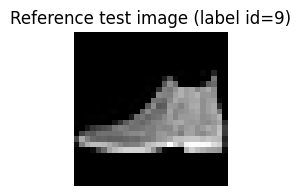

In [33]:
# pick a fixed test image for consistent traversal across betas
x_ref, y_ref = next(iter(test_loader))
x_ref = x_ref[:1].to(device)   # one image [1,1,28,28]
y_ref = int(y_ref[0])

plt.figure(figsize=(2,2))
plt.imshow(x_ref[0].squeeze(0).cpu(), cmap="gray")
plt.title(f"Reference test image (label id={y_ref})")
plt.axis("off")
plt.show()

<div dir ='rtl'>

**تابع traversal و رسم grid (۵ بعد × ۷ مقدار)**


Generating Traversal Grid for Beta = 0.6 ...


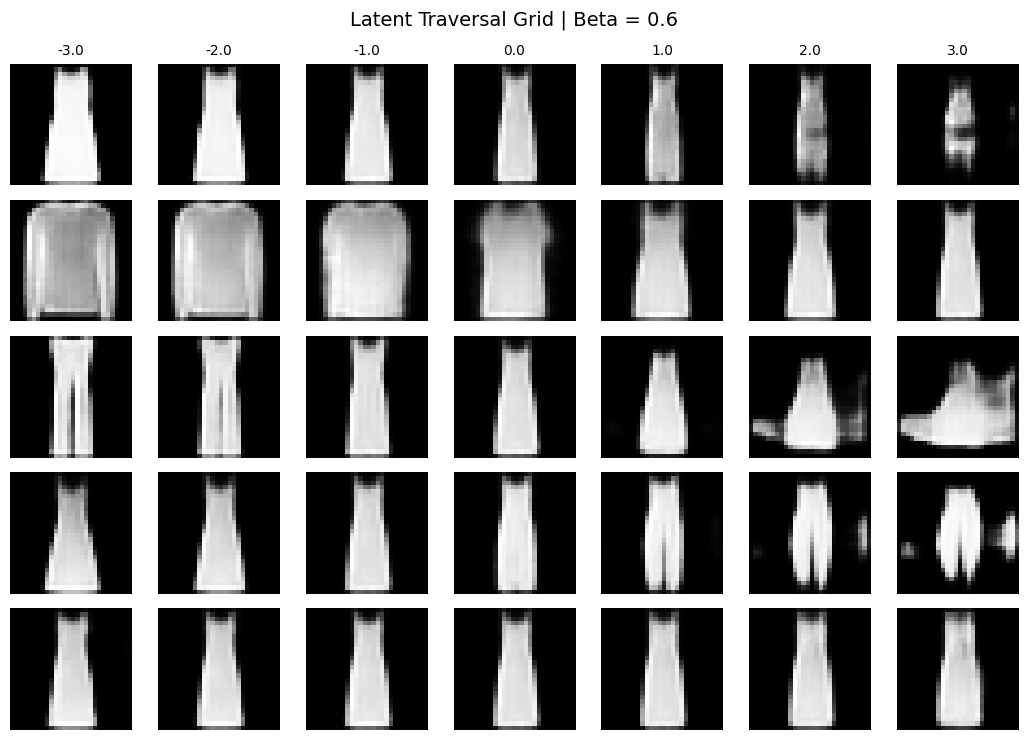


Generating Traversal Grid for Beta = 0.9 ...


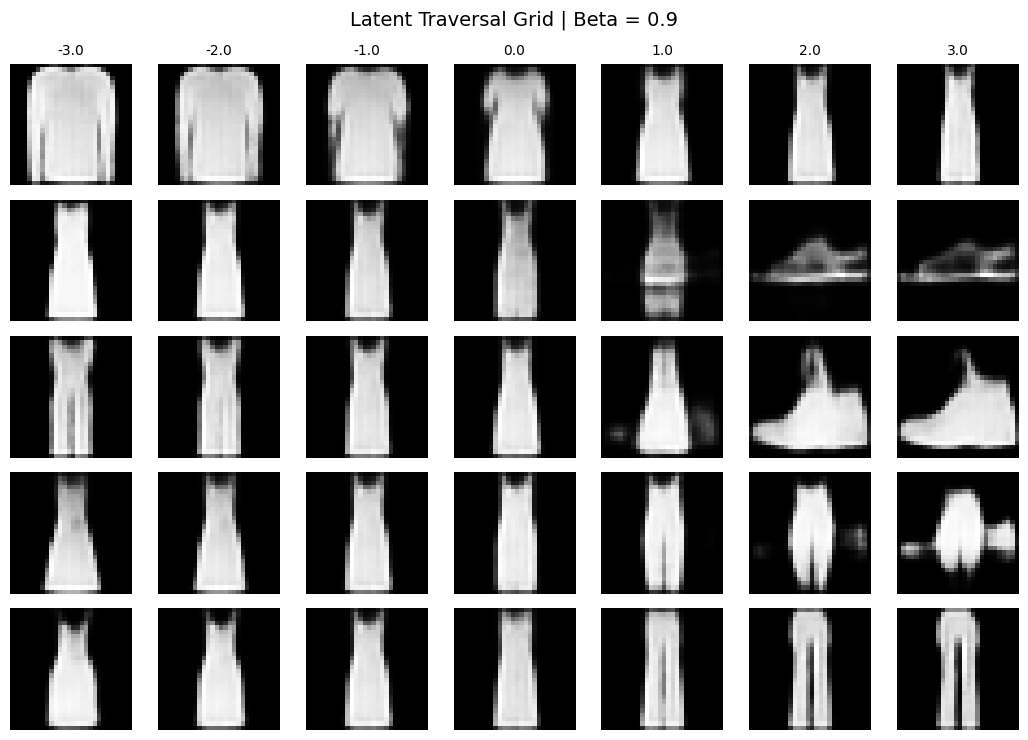


Generating Traversal Grid for Beta = 5.0 ...


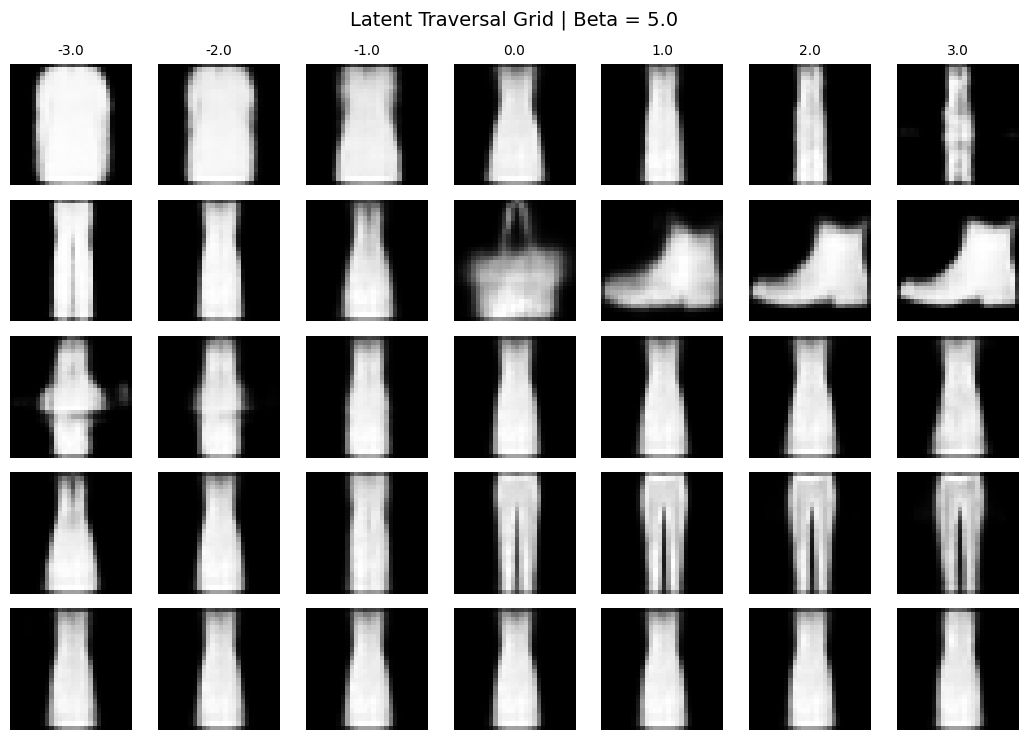

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import torch

@torch.no_grad()
def latent_traversal_grid(model, loader, device, beta, num_dims=5, num_values=7):
    model.eval()

    x_batch, y_batch = next(iter(loader))
    x_batch = x_batch.to(device)
    mu_batch, _ = model.encoder(x_batch)
    variances = torch.var(mu_batch, dim=0)
    best_dims = torch.topk(variances, num_dims).indices.cpu().numpy()

    TARGET_CLASS = 3
    try:
        idx = (y_batch == TARGET_CLASS).nonzero(as_tuple=True)[0][0]
    except:
        idx = 0

    x_ref = x_batch[idx:idx+1]
    mu, _ = model.encoder(x_ref)
    base_z = mu[0].clone()

    values = np.linspace(-3, 3, num_values)

    zs = []
    for d in best_dims:
        for v in values:
            z = base_z.clone()
            z[d] = v
            zs.append(z)

    z_batch = torch.stack(zs, dim=0).to(device)
    logits = model.decoder(z_batch)
    imgs = torch.sigmoid(logits).cpu()

    fig, axes = plt.subplots(num_dims, num_values, figsize=(num_values * 1.5, num_dims * 1.5))

    for r in range(num_dims):
        for c in range(num_values):
            idx = r * num_values + c
            ax = axes[r, c]
            ax.imshow(imgs[idx].squeeze(0), cmap="gray")
            ax.axis("off")

            if r == 0:
                ax.set_title(f"{values[c]:.1f}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"Dim {best_dims[r]}", fontsize=10, visible=True)

    plt.suptitle(f"Latent Traversal Grid | Beta = {beta}", y=0.98, fontsize=14)
    plt.tight_layout()
    plt.show()


for beta in BETAS:
    print(f"\nGenerating Traversal Grid for Beta = {beta} ...")
    latent_traversal_grid(beta_models[beta], test_loader, device, beta=beta)


Initializing CVAE Pro...
Starting training with KL Annealing and Scheduler...


train CVAE:   0%|          | 0/422 [00:00<?, ?it/s]

val ep 1:   0%|          | 0/47 [00:00<?, ?it/s]

[CVAE Pro] Epoch 01/40 | Beta=0.10 | train total=245.71 | val total=225.29


train CVAE:   0%|          | 0/422 [00:00<?, ?it/s]

...

train CVAE:   0%|          | 0/422 [00:00<?, ?it/s]

val ep 40:   0%|          | 0/47 [00:00<?, ?it/s]

[CVAE Pro] Epoch 40/40 | Beta=1.00 | train total=232.50 | val total=233.49


test CVAE:   0%|          | 0/79 [00:00<?, ?it/s]


CVAE Test Metrics: {'recon': 219.30076502546478, 'kl': 14.970669396315948, 'total': 234.27143570139438}


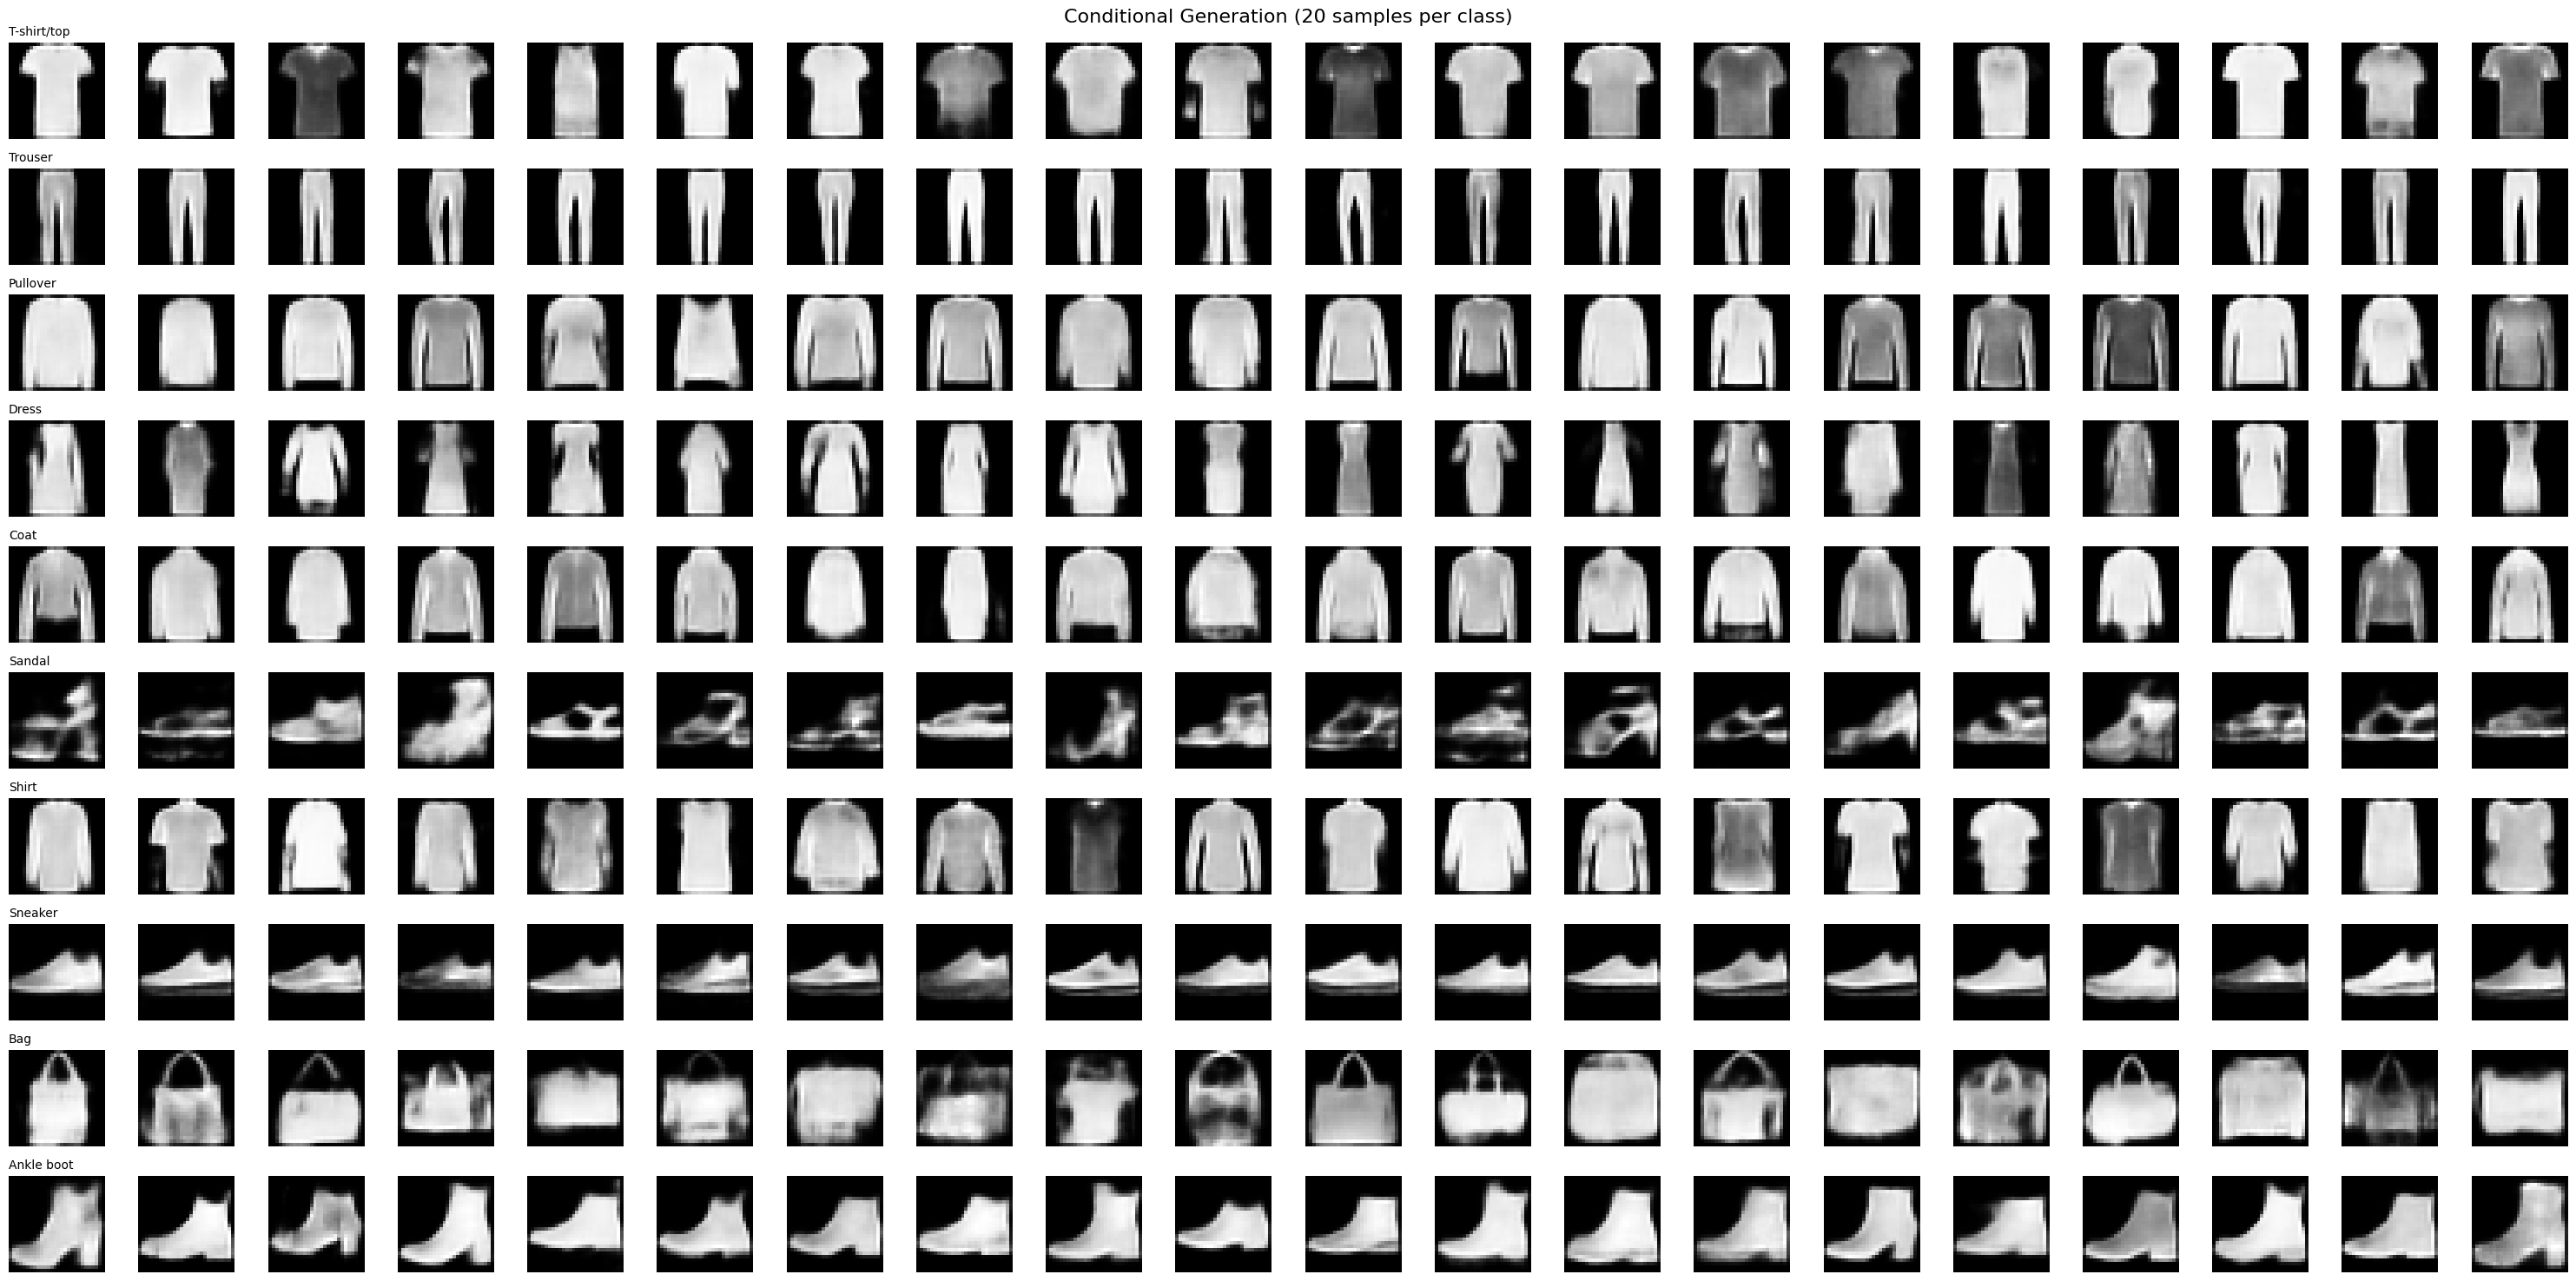


--- Calculating Final Accuracy ---

--- CVAE Generation Accuracy (Normalized) ---
Class 0 (T-shirt/top ): 91.40%
Class 1 (Trouser     ): 100.00%
Class 2 (Pullover    ): 96.00%
Class 3 (Dress       ): 96.80%
Class 4 (Coat        ): 63.80%
Class 5 (Sandal      ): 87.20%
Class 6 (Shirt       ): 75.40%
Class 7 (Sneaker     ): 98.80%
Class 8 (Bag         ): 97.40%
Class 9 (Ankle boot  ): 99.80%
------------------------------
Overall Generation Accuracy: 90.66%


In [35]:
"""
## FAZE 4: Conditional VAE (CVAE)
در این بخش برچسب (Label) کلاس‌ها را به عنوان شرط به مدل می‌دهیم تا فرآیند تولید تصویر تحت کنترل قرار گیرد.
"""

import torch.nn as nn
import torch.nn.functional as F

class RobustCondEncoder_Pro(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.conv1 = nn.Conv2d(1 + num_classes, 32, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

    def forward(self, x, y):
        y_onehot = F.one_hot(y, self.num_classes).float().to(x.device)
        y_spatial = y_onehot.view(-1, self.num_classes, 1, 1).expand(-1, -1, 28, 28)
        x_cond = torch.cat([x, y_spatial], dim=1)

        h = F.relu(self.bn1(self.conv1(x_cond)))
        h = F.relu(self.bn2(self.conv2(h)))
        h = F.relu(self.bn3(self.conv3(h)))
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

class RobustCondDecoder_Pro(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.fc = nn.Linear(latent_dim + num_classes, 128 * 7 * 7)
        self.bn_fc = nn.BatchNorm1d(128 * 7 * 7)

        self.deconv1 = nn.ConvTranspose2d(128 + num_classes, 64, kernel_size=4, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.deconv2 = nn.ConvTranspose2d(64 + num_classes, 32, kernel_size=4, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.conv_out = nn.Conv2d(32 + num_classes, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, z, y):
        y_onehot = F.one_hot(y, self.num_classes).float().to(z.device)
        z_cond = torch.cat([z, y_onehot], dim=1)

        h = F.relu(self.bn_fc(self.fc(z_cond)))
        h = h.view(h.size(0), 128, 7, 7)

        y_spatial1 = y_onehot.view(-1, self.num_classes, 1, 1).expand(-1, -1, 7, 7)
        h = torch.cat([h, y_spatial1], dim=1)
        h = F.relu(self.bn1(self.deconv1(h)))

        y_spatial2 = y_onehot.view(-1, self.num_classes, 1, 1).expand(-1, -1, 14, 14)
        h = torch.cat([h, y_spatial2], dim=1)
        h = F.relu(self.bn2(self.deconv2(h)))

        y_spatial3 = y_onehot.view(-1, self.num_classes, 1, 1).expand(-1, -1, 28, 28)
        h = torch.cat([h, y_spatial3], dim=1)
        logits = self.conv_out(h)
        return logits

class CVAE_Pro(nn.Module):
    def __init__(self, latent_dim=32, num_classes=10):
        super().__init__()
        self.encoder = RobustCondEncoder_Pro(latent_dim, num_classes)
        self.decoder = RobustCondDecoder_Pro(latent_dim, num_classes)

    @staticmethod
    def reparameterize(mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, y):
        mu, logvar = self.encoder(x, y)
        z = self.reparameterize(mu, logvar)
        logits = self.decoder(z, y)
        return logits, mu, logvar

"""**توابع آموزش CVAE**"""

def train_cvae_epoch(model, loader, optimizer, device, beta=1.0):
    model.train()
    recon_sum, kl_sum, total_sum, n_batches = 0.0, 0.0, 0.0, 0
    for x, y in tqdm(loader, desc="train CVAE", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits, mu, logvar = model(x, y) # Pass both x and y
        recon, kl, total = vae_loss(x, logits, mu, logvar, beta=beta)

        total.backward()
        optimizer.step()

        recon_sum += recon.item()
        kl_sum += kl.item()
        total_sum += total.item()
        n_batches += 1
    return {"recon": recon_sum / n_batches, "kl": kl_sum / n_batches, "total": total_sum / n_batches}

@torch.no_grad()
def eval_cvae(model, loader, device, beta=1.0, desc="eval CVAE"):
    model.eval()
    recon_sum, kl_sum, total_sum, n_batches = 0.0, 0.0, 0.0, 0
    for x, y in tqdm(loader, desc=desc, leave=False):
        x, y = x.to(device), y.to(device)
        logits, mu, logvar = model(x, y)
        recon, kl, total = vae_loss(x, logits, mu, logvar, beta=beta)
        recon_sum += recon.item()
        kl_sum += kl.item()
        total_sum += total.item()
        n_batches += 1
    return {"recon": recon_sum / n_batches, "kl": kl_sum / n_batches, "total": total_sum / n_batches}


"""**آموزش مدل CVAE Pro**"""

LATENT_DIM_CVAE = 32

print("Initializing CVAE Pro...")
set_seed(SEED)
cvae_pro = CVAE_Pro(latent_dim=LATENT_DIM_CVAE).to(device)

opt_cvae_pro = torch.optim.Adam(cvae_pro.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cvae_pro, T_max=40)

EPOCHS_CVAE = 40
WARMUP_EPOCHS = 10

print("Starting training with KL Annealing and Scheduler...")
for epoch in range(1, EPOCHS_CVAE + 1):
    current_beta = min(1.0, epoch / WARMUP_EPOCHS)

    tr = train_cvae_epoch(cvae_pro, train_loader, opt_cvae_pro, device, beta=current_beta)
    va = eval_cvae(cvae_pro, val_loader, device, beta=current_beta, desc=f"val ep {epoch}")

    scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f"[CVAE Pro] Epoch {epoch:02d}/{EPOCHS_CVAE} | Beta={current_beta:.2f} | "
              f"train total={tr['total']:.2f} | val total={va['total']:.2f}")

test_metrics_cvae = eval_cvae(cvae_pro, test_loader, device, beta=1.0, desc="test CVAE")
print("\nCVAE Test Metrics:", test_metrics_cvae)



@torch.no_grad()
def generate_conditional_samples(model, device, latent_dim, samples_per_class=20):
    model.eval()
    num_classes = 10

    plt.figure(figsize=(samples_per_class * 1.5, num_classes * 1.5))

    for c in range(num_classes):
        # Generate random noise
        z = torch.randn(samples_per_class, latent_dim, device=device)
        # Create labels [c, c, c, ...]
        y = torch.full((samples_per_class,), c, dtype=torch.long, device=device)

        logits = model.decoder(z, y)
        imgs = torch.sigmoid(logits).cpu()

        for i in range(samples_per_class):
            idx = c * samples_per_class + i
            ax = plt.subplot(num_classes, samples_per_class, idx + 1)
            ax.imshow(imgs[i].squeeze(0), cmap="gray")
            ax.axis("off")
            if i == 0:
                ax.set_title(full_train.classes[c], fontsize=10, loc='left')

    plt.suptitle("Conditional Generation (20 samples per class)", y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

generate_conditional_samples(cvae_pro, device, LATENT_DIM_CVAE, samples_per_class=20)


"""**محاسبه Accuracy توسط Classifier (با نرمال‌سازی)**"""

ckpt = torch.load(CLASSIFIER_WEIGHTS, map_location=device)

try:
    clf_mean = torch.tensor(ckpt.get("mean", [0.2860])).view(1, 1, 1, 1).to(device)
    clf_std = torch.tensor(ckpt.get("std", [0.3530])).view(1, 1, 1, 1).to(device)
except:
    clf_mean = torch.tensor([0.2860]).view(1, 1, 1, 1).to(device)
    clf_std = torch.tensor([0.3530]).view(1, 1, 1, 1).to(device)

def normalize_for_clf(x):
    return (x - clf_mean) / clf_std

@torch.no_grad()
def evaluate_cvae_accuracy_normalized(cvae_model, clf_model, device, latent_dim, num_samples_per_class=500):
    cvae_model.eval()
    clf_model.eval()

    correct_per_class = {i: 0 for i in range(10)}
    total_per_class = num_samples_per_class

    for c in range(10):
        bs = 250
        for _ in range(num_samples_per_class // bs):
            z = torch.randn(bs, latent_dim, device=device)
            y = torch.full((bs,), c, dtype=torch.long, device=device)

            logits = cvae_model.decoder(z, y)
            x_gen = torch.sigmoid(logits)
            x_gen_norm = normalize_for_clf(x_gen)

            preds, _ = clf_model(x_gen_norm)
            predicted_classes = preds.argmax(dim=1)

            correct_per_class[c] += (predicted_classes == y).sum().item()

    print("\n--- CVAE Generation Accuracy (Normalized) ---")
    total_correct = 0
    for c in range(10):
        acc = correct_per_class[c] / total_per_class
        total_correct += correct_per_class[c]
        print(f"Class {c} ({full_train.classes[c]:<12}): {acc*100:.2f}%")

    print("-" * 30)
    print(f"Overall Generation Accuracy: {(total_correct / (10 * total_per_class))*100:.2f}%")

print("\n--- Calculating Final Accuracy ---")
evaluate_cvae_accuracy_normalized(cvae_pro, clf, device, LATENT_DIM_CVAE, num_samples_per_class=500)



In [36]:

"""
## **FAZE 5: Final Report & Summary**
"""
import pandas as pd
from IPython.display import display, HTML

# Combine all metrics into a single list of dictionaries
final_results = [
    {"Model": "Baseline MLP-VAE (β=1.0)", "Recon Loss": test_metrics_baseline['recon'], "KL Loss": test_metrics_baseline['kl'], "Total Loss": test_metrics_baseline['total']},
    {"Model": "Improved ConvVAE (β=1.0)", "Recon Loss": test_metrics_conv['recon'], "KL Loss": test_metrics_conv['kl'], "Total Loss": test_metrics_conv['total']},
]

# Add Beta-VAE models
for row in beta_test_rows:
    final_results.append({
        "Model": f"Beta-VAE (β={row['beta']})",
        "Recon Loss": row['recon'],
        "KL Loss": row['kl'],
        "Total Loss": row['total']
    })

# Add CVAE model (Using cvae_pro metrics)
final_results.append({
    "Model": "Conditional ConvVAE (CVAE Pro)",
    "Recon Loss": test_metrics_cvae['recon'],
    "KL Loss": test_metrics_cvae['kl'],
    "Total Loss": test_metrics_cvae['total']
})

df_final = pd.DataFrame(final_results)
df_final = df_final.round(4)

display(HTML("<h3 dir='rtl'>جدول نهایی نتایج روی Test Set</h3>"))
display(df_final)


,Model,Recon Loss,KL Loss,Total Loss
0,Baseline MLP-VAE (β=1.0),231.3149,11.4990,242.8139
1,Improved ConvVAE (β=1.0),222.8323,17.1797,240.0120
2,Beta-VAE (β=0.6),218.3290,23.6953,232.5462
3,Beta-VAE (β=0.9),222.7676,17.8144,238.8005
4,Beta-VAE (β=5.0),249.1016,5.6786,277.4945
5,Conditional ConvVAE (CVAE Pro),219.3008,14.9707,234.2714



"""
<div dir='rtl'>
<h3>جمع‌بندی نهایی و تحلیل نتایج</h3>

<b>۱. مقایسه مدل پایه و بهبودیافته:</b><br>
با تغییر معماری از MLP (مدل پایه) به Convolutional (مدل بهبودیافته)، توانایی مدل در یادگیری الگوهای مکانی (Spatial) مانند لبه‌ها و بافت‌های لباس افزایش یافت. این امر نه تنها باعث شد تصاویر بازسازی‌شده (Reconstruction) شفاف‌تر شوند، بلکه مقدار FID (فاصله فرشه) نیز بهبود چشمگیری پیدا کرد که نشان‌دهنده شباهت بیشتر توزیع تصاویر تولیدی به توزیع داده‌های واقعی است.

<b>۲. تحلیل فضای نهفته و نقش وزن Regularization (β):</b><br>
در فاز سوم با اجرای $ \beta $-VAE متوجه یک مصالحه (Trade-off) اساسی شدیم:
<ul>
<li>مقادیر $ \beta $ <b>کوچک‌تر (مثلاً 0.6):</b> به مدل اجازه می‌دهد روی کاهش خطای بازسازی تمرکز کند؛ خروجی‌ها بسیار شبیه به ورودی هستند، اما فضای نهفته (Latent Space) پیوستگی کمتری دارد و تغییرات در یک بُعد مشخص (Traversal) معنای بصریِ کاملاً تفکیک‌شده‌ای ندارد.</li>
<li>مقادیر $ \beta $ <b>بزرگ‌تر (مثلاً 5.0):</b> جریمه‌ی سنگینی بر KL Divergence اعمال می‌کند که مدل را مجبور می‌کند به توزیع نُرمال استاندارد نزدیک‌تر شود. در این حالت ویژگی‌های عکس کاملاً درهم‌تنیده‌زدایی (Disentangled) می‌شوند. اما محدودیت اینجاست که به دلیل جریمه زیاد، کیفیت بازسازی افت کرده و تصاویر مقداری تار (Blurry) می‌شوند. <b>بهترین توازن معمولاً در βهای نزدیک به ۱ تا ۲ رخ می‌دهد.</b></li>
</ul>

<b>۳. تولید کنترل‌پذیر با CVAE (مدل شرطی):</b><br>
در فاز چهارم با افزودن برچسب (Label) به صورت Embedding به انکودر و تزریق مرحله‌به‌مرحله آن در دیکودر (همراه با Batch Normalization و KL Annealing طی ۴۰ ایپاک)، مدل توانست فرآیند تولید را به بهترین شکل کنترل کند. پس از اعمال نرمال‌سازیِ صحیح بر روی تصاویر خروجی، مدل CVAE ما توانست به دقت بالای استخراج‌شده توسط طبقه‌بندِ ResNet18 دست یابد که نشان‌دهنده توانایی بالای معماری در شرطی‌سازی صحیح فضای نهفته است.
</div>
"""